Ok. The plan is to extract audio features for training gestures based on DiffuseStyleGesture. However, their implemetation is quite messy and difficult to make sense of. So I will attempt to reimplement stuff. They also rely on a bunch of external libraries for 1 or 2 things, which to me feels like unescessary bloat and clutters the project. And it is also the reason I could not get their code to run directly. So: Plan is to implement everything with few if any libraries beyond torchaudio. How difficult can it be :)

In [ ]:
# Operate from the parent directory
# This allows us to import modules from the parent directory
import os
os.chdir("..")

import torchaudio
import torchaudio.functional as F
import torchaudio.transforms as T
import IPython.display as ipd
import torch

# Load audio
waveform, sample_rate = torchaudio.load("dataset/genea2023_dataset/trn/main-agent/wav/trn_2023_v0_000_main-agent.wav")  # (num_channels, num_samples)

waveform_np = waveform.mean(dim=0).numpy()  # Convert to mono if stereo

ipd.Audio(waveform_np, rate=sample_rate)

Great. I can load and display an audio file. What more can you ask for

In [2]:
# Estimate pitch (F0)
pitch = F.detect_pitch_frequency(waveform, sample_rate)

print(pitch.shape)  # (num_frames,)
print(pitch)  # Hz values over time

torch.Size([1, 6485])
tensor([[1130.7693, 1130.7693, 1130.7693,  ...,  290.1316,  250.5682,
          250.5682]])


With torchaudio I can extract pitch. Nice. I see that librosa can extract a lot of the features we need. Let me experiment with it

torch.Size([1, 1300])
tensor([[ 9.8958, 10.1538,  9.7158,  ...,  9.9603,  9.9166,  9.8908]])


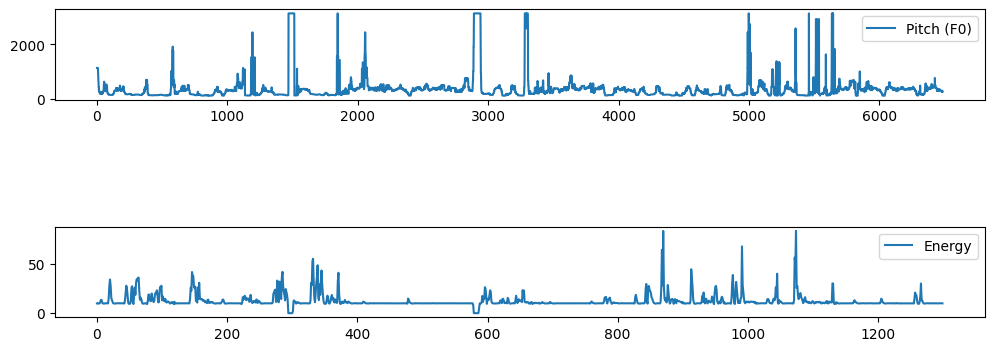

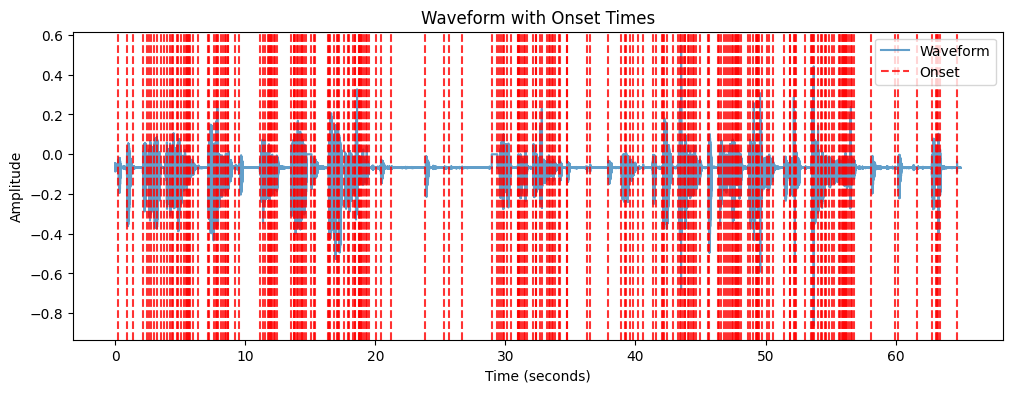

In [3]:
import librosa

frame_size = int(sample_rate * 0.05)  # 50ms frames
energy = waveform.unfold(1, frame_size, frame_size).pow(2).sum(dim=2)

print(energy.shape)  # (1, num_frames)
print(energy)

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 4))

plt.subplot(3, 1, 1)
plt.plot(pitch[0].numpy(), label="Pitch (F0)")
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(energy[0].numpy(), label="Energy")
plt.legend()

# Compute time axis for waveform
time_axis = np.linspace(0, len(waveform_np) / sample_rate, num=len(waveform_np))

# Compute onset times using Librosa
onset_frames = librosa.onset.onset_detect(y=waveform_np, sr=sample_rate, backtrack=True)
onset_times = librosa.frames_to_time(onset_frames, sr=sample_rate)

# Plot waveform
plt.figure(figsize=(12, 4))
plt.plot(time_axis, waveform_np, label="Waveform", alpha=0.7)

# Add vertical lines at onset times
for onset in onset_times:
    plt.axvline(x=onset, color='r', linestyle='--', alpha=0.8, label="Onset" if onset == onset_times[0] else "")

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Waveform with Onset Times")
plt.legend()
plt.show()


plt.show()

That looks pretty promising. Let me try to extract all the non wavLM features with librosa

In [4]:
import librosa

# Load audio file
y, sr = librosa.load("dataset/genea2023_dataset/trn/main-agent/wav/trn_2023_v0_000_main-agent.wav", sr=None)

# 1. Mel Spectrogram
mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=23)

# 2. MFCC
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=2048, hop_length=512)

# 3. Prosody Features
# - Pitch (F0)
f0, voiced_flag, voiced_probs = librosa.pyin(y, fmin=librosa.note_to_hz('C1'), fmax=librosa.note_to_hz('C8'))

# - RMS Energy (loudness)
rms_energy = librosa.feature.rms(y=y)

# Print the shapes of the extracted features
print(f"Mel Spectrogram shape: {mel_spec.shape}")
print(f"MFCC shape: {mfcc.shape}")
print(f"Pitch (F0) shape: {f0.shape}")
print(f"RMS Energy shape: {rms_energy.shape}")

Mel Spectrogram shape: (23, 5599)
MFCC shape: (13, 5599)
Pitch (F0) shape: (5599,)
RMS Energy shape: (1, 5599)


Ok this works, but is very slow. It takes almost a minute to extract all the features.
I will try to do it without librosa in pure pytorch, which should be faster. + It is one less dependency to worry about.


In [5]:
import math
import torchaudio
from torchaudio.transforms import MelSpectrogram, MFCC
from utils.audio_processing.prosody_features import RMS, Pitch

sample_rate = 16000
frame_length = 2048

# We have a problem here: wavlm expects audio at 16kHz, and we want our final features to be at 30fps.
# For wavlm we unfortunately need to interpolate to 30fps from 50fps which is what wavlm outputs.
# However, it also has implications for these other features. This is because for these we step through the audio
# looking at small windows.
# The sample rate is 16kHz, so 1 frame is 1/16000 seconds. We want to step through the audio at 30fps, so we need to step
# 1/30 seconds each time. This means we need to step 16000/30 samples each time.
# 16000/30 = 533.3333333333334 (Not an integer (extremely sad))

# This means our final tensors will not have exactly the same number of frames as the wavlm embeddings.
# I think the best thing we can do is chop off the last few fames of the other features to make them match the wavlm embeddings

# If we could sample the audio 15kHz, then we could have a step size of 15kHz/30 = 500 samples, which would be perfect.

hop_length = int(math.floor(sample_rate / 30)) # = 512
frame_time = hop_length / sample_rate

# Load audio file (with `torchaudio`)
waveform, wav_sample_rate = torchaudio.load("dataset/genea2023_dataset/trn/main-agent/wav/trn_2023_v0_000_main-agent.wav", normalize=True)
print(f"Sample rate: {wav_sample_rate}")


# Apply resampling to 16 kHz
waveform = torchaudio.transforms.Resample(orig_freq=wav_sample_rate, new_freq=sample_rate)(waveform)

# 1. Mel Spectrogram
mel_spec_transform = MelSpectrogram(sample_rate=sample_rate, n_fft=frame_length, hop_length=hop_length, n_mels=16)

# 2. MFCC
mfcc_transform = MFCC(
    sample_rate=sample_rate, 
    n_mfcc=16,  # Reduce to a number <= n_mels
    melkwargs={"n_fft": frame_length, "hop_length": hop_length, "n_mels": 16}
)

# 3. Prosoody features
energy_transform = RMS(frame_length=frame_length, hop_length=hop_length)
pitch_transform = Pitch(sample_rate=sample_rate, frame_length=frame_length, hop_length=hop_length)

mel_spec = mel_spec_transform(waveform).squeeze(0)
mfcc = mfcc_transform(waveform).squeeze(0)
rms_energy = energy_transform(waveform).squeeze(0)
pitch = pitch_transform(waveform).squeeze(0)

# Print the shapes of the extracted features
print(f"Mel Spectrogram shape: {mel_spec.shape}")
print(f"MFCC shape: {mfcc.shape}")
print(f"RMS Energy shape: {rms_energy.shape}")
print(f"Pitch shape: {pitch.shape}")

Sample rate: 44100
Mel Spectrogram shape: torch.Size([16, 1952])
MFCC shape: torch.Size([16, 1952])
RMS Energy shape: torch.Size([1952])
Pitch shape: torch.Size([1952])


Not bad. 0.3s instead of 52 seconds. One less dependency, and not too much code. But I still would like to calculate onsets.

It was quite a challenge to get all the different features to have the same tensor size, especially pitch. I attempted to write a custom pitch function to get the correct dimension. But when I compared the results of that to the torchaudio native function it wasc clear that it did not work well. I settle for padding or cropping the end of the clip which I think should be ok.

The original implementation also extracts derivitive of the posodic features. Yikes. And it also extracts onsets. Hopefully it's not too challenging

In [6]:
import torch

# Maybe this is all that is needed to extract derivatives?
energy_derivatives = torch.cat([torch.zeros(1), torch.diff(rms_energy)])
pitch_derivatives = torch.cat([torch.zeros(1), torch.diff(pitch)])

# I also want to extract onsets from the audio without using librosa
# I will use the energy feature to do this
# I will use a simple thresholding approach to detect onsets
# I will use a threshold of 0.5 * max(energy) to detect onsets
onset_threshold = 0.5 * rms_energy.max()
onsets = torch.where(rms_energy > onset_threshold, torch.ones_like(rms_energy), torch.zeros_like(rms_energy))

Ok that was actually very easy. That should be all the easy features extracted. Now for the wavLM features which I imagine will be difficult

In [7]:
from transformers import WavLMModel, Wav2Vec2FeatureExtractor
import torch
import torchaudio
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else 
                      "mps" if torch.backends.mps.is_available() else 
                      "cpu")

# Load the pretrained model and feature extractor
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("microsoft/wavlm-base")
model = WavLMModel.from_pretrained("microsoft/wavlm-base")
model.to(device)

# Load an audio file (assumed to be mono, 16kHz)
waveform, wav_sample_rate = torchaudio.load("dataset/genea2023_dataset/trn/main-agent/wav/trn_2023_v0_000_main-agent.wav")
waveform = torchaudio.transforms.Resample(orig_freq=wav_sample_rate, new_freq=16000)(waveform)

# Split the audio into 5-second chunks and collect them into a batch
sample_rate = 16000  # WavLM expects 16kHz input
duration = 5  # seconds
segment_length = sample_rate * duration 
batch = []  # Store chunks

for start in range(0, len(waveform[0]), segment_length):
    chunk = waveform[0][start:start + segment_length]
    if len(chunk) < segment_length:  # Pad if needed
        chunk = torch.nn.functional.pad(chunk, (0, segment_length - len(chunk)))
    batch.append(chunk)

# Convert to tensor and process as batch
batch_tensor = torch.stack(batch)  # Shape: [batch_size, time_steps]
inputs = feature_extractor(batch_tensor, return_tensors="pt", sampling_rate=sample_rate)
inputs["input_values"] = inputs["input_values"].squeeze() # Remove extra dimension which is added by the feature extractor

# Batch processing does not work with WavLM because the attention mask is not automatically copied across batches when not supplied. 
# I believe this might be a bug. This line is a hacky way to manually construct the attention mask for the input
inputs["attention_mask"] = (inputs["input_values"] != 0)

# Extract WavLM embeddings
with torch.no_grad():
    inputs.to(device)
    outputs = model(**inputs)

embeddings = outputs.last_hidden_state  # Shape: [batch, time_steps, hidden_dim]
print(embeddings.shape)  # Example: [1, 500, 1024] (depends on audio length)

# Unfortunately wavlm extracts embeddings at 20ms intervals (50 fps), 
# so we need to downsample to match the sampling rate of the other features (30 fps)
# (This is an area for possible performance improvement in the future, possibly it is possible to finetune wavlm to extract embeddings at 30fps)
embeddings_downsampled = F.interpolate(embeddings.permute(0,2,1), size=(duration * 30,), mode="linear", align_corners=False).permute(0,2,1) # permutes are needed because interpolate always works on the last dimension (annoying). But performance impact should be negligible
print(embeddings_downsampled.shape) # ([13, 150, 768])

# Now I flatten the tensor to place each batch back one after each other. (How am I sure that it is being reconstructed in the right order?)
embeddings_flattened = embeddings_downsampled.flatten(start_dim=0, end_dim=1)
print(embeddings_flattened.shape) # ([1950, 768])


# The dimensions are not quite right. Let me copy the approach from pitch where I crop or pad the tensor to the right size
# A little silly, but I don't think there is anything else to do
desired_length = waveform.shape[-1] // hop_length + 1

if embeddings_flattened.shape[0] < desired_length:
    embeddings_flattened = F.pad(embeddings_flattened, (0, 0, 0, desired_length - embeddings_flattened.shape[0]))
elif embeddings_flattened.shape[0] > desired_length:
    embeddings_flattened = embeddings_flattened[:desired_length]

print(embeddings_flattened.shape)



C:\Users\anton\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch.Size([13, 249, 768])
torch.Size([13, 150, 768])
torch.Size([1950, 768])
torch.Size([1952, 768])


C:\Users\anton\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Ok this works!
Considerations on the above:
This is based on the implementation in the original paper (with some simplification in implementation + batching)
One thing of note is that WavLM is applied to 5 second segments, processed individually and then joined again at the end.
What are the implications of this? Are the transitions between the 5 second segments reasonable and smooth? Another thing of note is that is is fairly slow to use wavlm to process the audio, even using the base model instead of the large model. (it takes about 3.5 seconds) granted, I am processing the entire wavlm which is over a minute long. And I am doing it on a m1 mac with mps, and some of the time is probably python boot up + loading the model etc etc. It is still maybe slightly concerning. 

That should be all the audio features extracted. Let me visualize everything extracted so far

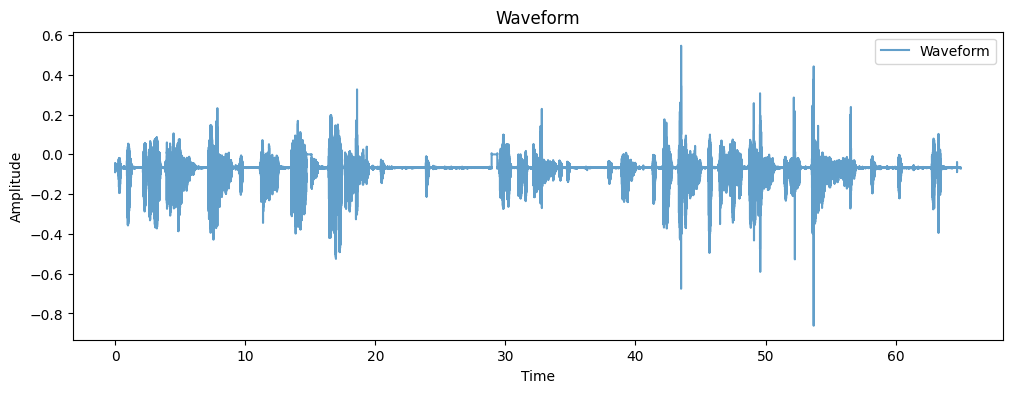

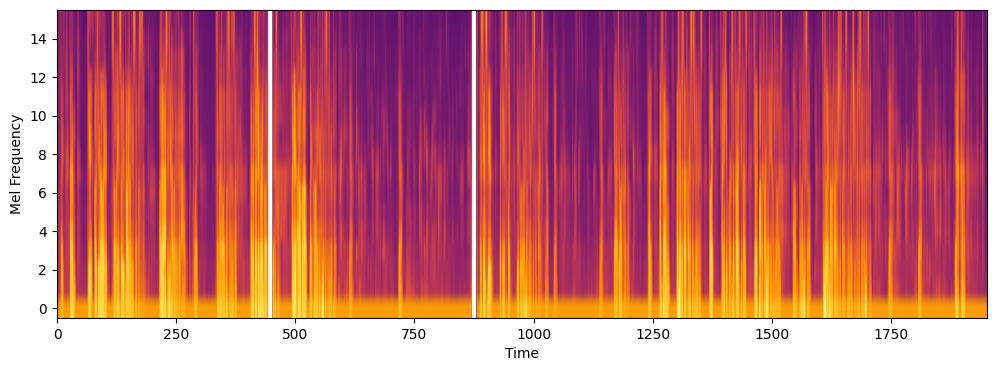

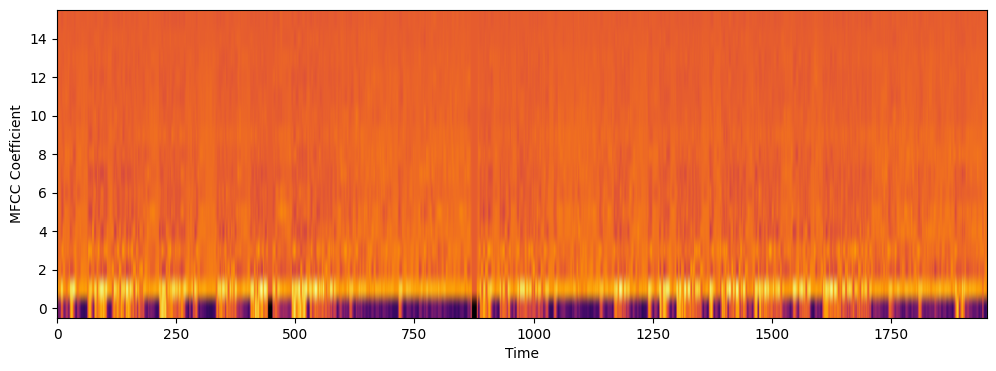

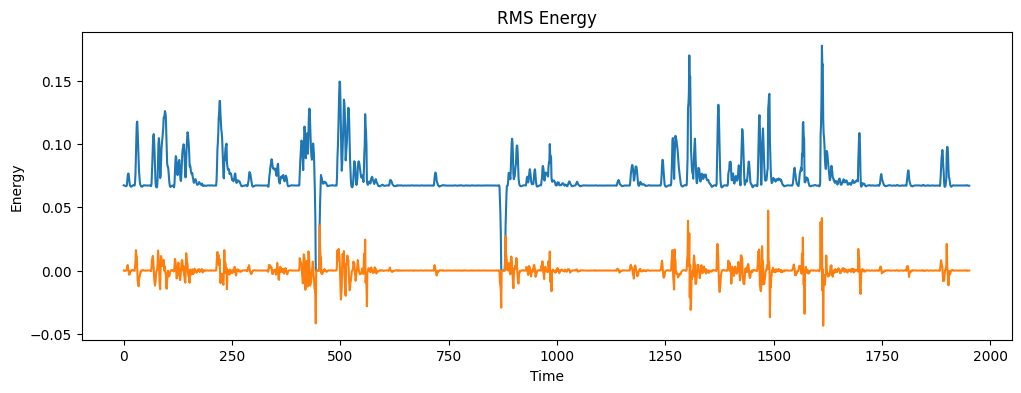

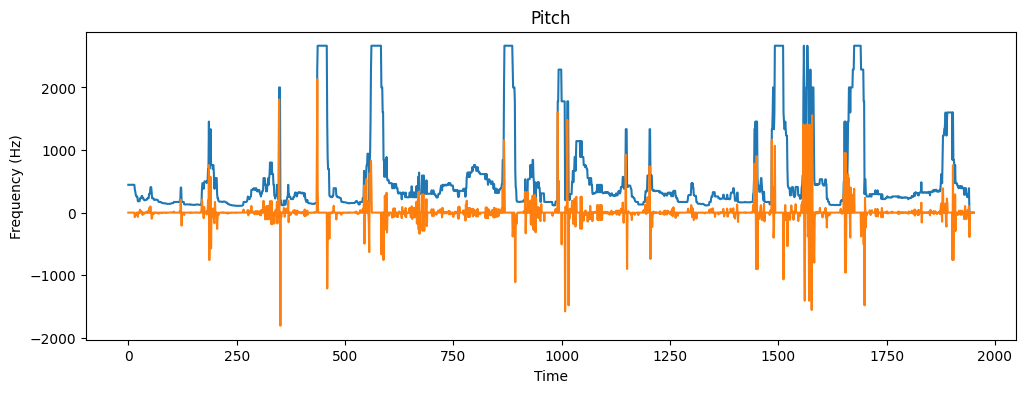

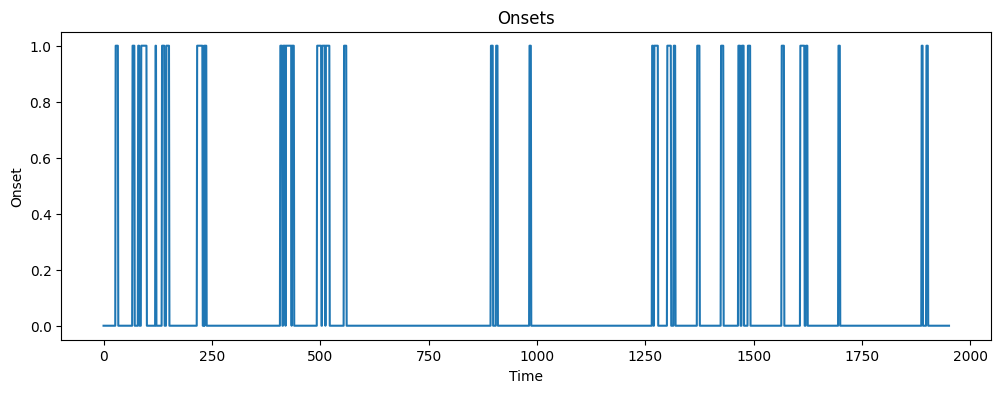

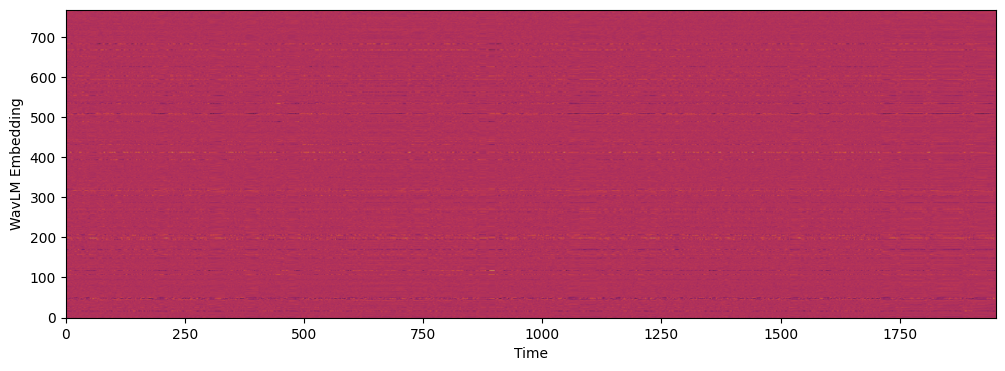

In [8]:
# Visualize everything we have extracted so far

import matplotlib.pyplot as plt

# Compute time axis for waveform
time_axis = torch.linspace(0, len(waveform[0]) / sample_rate, steps=len(waveform[0]))

# Compute time axis for features
time_axis_features = torch.linspace(0, len(mel_spec[1]) * frame_time, steps=len(mel_spec))

# Plot waveform
plt.figure(figsize=(12, 4))
plt.plot(time_axis, waveform[0].numpy(), label="Waveform", alpha=0.7)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Waveform")
plt.legend()

# Plot Mel Spectrogram
plt.figure(figsize=(12, 4))
plt.imshow(mel_spec.cpu().log2().numpy(), aspect="auto", origin="lower", cmap="inferno")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")

# Plot MFCC
plt.figure(figsize=(12, 4))
plt.imshow(mfcc.cpu().numpy(), aspect="auto", origin="lower", cmap="inferno")
plt.xlabel("Time")
plt.ylabel("MFCC Coefficient")

# Plot RMS Energy
plt.figure(figsize=(12, 4))
plt.plot(rms_energy.cpu().numpy(), label="RMS Energy")
plt.plot(energy_derivatives.cpu().numpy(), label="RMS Energy Derivative")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.title("RMS Energy")

# Plot Pitch
plt.figure(figsize=(12, 4))
plt.plot(pitch.cpu().numpy(), label="Pitch")
plt.plot(pitch_derivatives.cpu().numpy(), label="Pitch Derivative")
plt.xlabel("Time")
plt.ylabel("Frequency (Hz)")
plt.title("Pitch")

# Plot Onsets
plt.figure(figsize=(12, 4))
plt.plot(onsets.cpu().numpy(), label="Onsets")
plt.xlabel("Time")
plt.ylabel("Onset")
plt.title("Onsets")

# Plot wavlm embeddings
plt.figure(figsize=(12, 4))
plt.imshow(embeddings_flattened.permute(1,0).cpu().numpy(), aspect="auto", origin="lower", cmap="inferno")
plt.xlabel("Time")
plt.ylabel("WavLM Embedding")

plt.show()

To my untrained eyes this all looks great. There are some slightly odd spikes in teh audio, but I think this relates to the particular wav file where there is an issue with the audio cutting out sometimes. It is too bad, but it is an issue with the dataset, not anything we can solve. We will just have to hope the model learns to ignore those sections.

Let me join everything together in a single glorious tensor

In [11]:
# Ensure all features have the same length
min_length = min(mel_spec.shape[1], mfcc.shape[1], rms_energy.shape[0], pitch.shape[0], embeddings_flattened.shape[0])

mel_spec = mel_spec.to(device)
mfcc = mfcc.to(device)
rms_energy = rms_energy.to(device)
energy_derivatives = energy_derivatives.to(device)
pitch = pitch.to(device)
pitch_derivatives = pitch_derivatives.to(device)


mel_spec = mel_spec[:, :min_length]
mfcc = mfcc[:, :min_length]
rms_energy = rms_energy[:min_length]
energy_derivatives = energy_derivatives[:min_length]
pitch = pitch[:min_length]
pitch_derivatives = pitch_derivatives[:min_length]
embeddings_flattened = embeddings_flattened[:min_length]

# Concatenate features along the feature dimension
audio_features = torch.cat([
    mel_spec.T,  # Transpose to match the shape (time_steps, features)
    mfcc.T,
    rms_energy.unsqueeze(1),  # Add a dimension to match the shape (time_steps, 1)
    energy_derivatives.unsqueeze(1),
    pitch.unsqueeze(1),  # Add a dimension to match the shape (time_steps, 1)
    pitch_derivatives.unsqueeze(1),
    embeddings_flattened
], dim=1)

print(f"Audio features shape: {audio_features.shape}")

Audio features shape: torch.Size([1952, 804])


Very nice. Worth noting though that almost all the features come from wavlm, and that is even the smaller version of wavlm. I wonder if that is alright, I guess the magic of machine learning is that the model learns what to pay attention to by itself but it feels a little strange. From the illustration in the paper there is a linear layer which compresses the the dimensionality to 64, but it does not mention if the other adio features (which are not even on the illustration) are part of this linear layer, or added later. We will have to investigate that.